# Trading Game #1 — Optimal Market-Neutral Multivariate Pair Trading - Rice commodity

**GAUSSIN Natacha**
**FOURREAU Mathis**

*ESILV IF3 - Commodities Markets and Models*
 
**Reference:** Yang, H., & Malik, A. (2024). *Optimal market-neutral multivariate pair trading on the cryptocurrency platform.* International Journal of Financial Studies, 12(3), 77.  
**GitHub (original code):** https://github.com/Hongshen-Yang/optimal-trading-technique

---

### Objective

The aim of this notebook is to replicate and adapt the **Optimal Trading Technique (OTT)** developend in the reference article written by Yang & Malik (2024) to the **rice commodity sector**.  
The original paper applies OTT to cryptocurrency/fiat currency pairs. Here, we adapt the approach: instead of a cryptocurrency as the anchor, we use the **Rice Futures contract** as the primary anchor, and a selection of rice-related equities as the trading universe.

### Key Adaptation from the Paper

| Original (Yang & Malik 2024) | This Notebook |
|---|---|
| Anchor: ETH (cryptocurrency) | Anchor: Rice Futures |
| Fiat currencies: USD, CAD, GBP, EUR | Equities: KRBL.NS, ADM, BG, DBA, AGRO (rice-related stocks) ...|
| Data: minute-frequency OHLCVT from Kraken | Data: daily OHLCV from Yahoo Finance / Bloomberg |
| Optimization: Gurobi (bi-objective) | Optimization: Gurobi (same formulation) |

### Notebook Structure

1. Setup & Data Loading
2. Data Cleaning & Exploration
3. Asset Screening (Correlation + Cointegration)
4. Spread Computation & Z-Score Signaling
5. Historical Analysis (Expected Returns & Risk)
6. Optimal Trading (Gurobi Optimization)
7. Simulation & Backtesting
8. Performance Evaluation (OTT vs Buy-and-Hold)
9. Conclusion

---
## 1. Setup & Data Loading

In [1]:
# ==========================
# IMPORTS
# ==========================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
from statsmodels.tsa.stattools import adfuller
import gurobipy as gp
from gurobipy import GRB

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

**Global parameters**

We define parameters that will be useful throughout the code :

Then we define the risk aversion parameter,`LAMBDA` = $\lambda$, that controls the trade-off between the return and risk in the Gurobi optimization. We set this parameter to the default value $1$ (default value set in the article). A higher value would be more conservative and a lower value would be more aggresive.

We set the transaction cost parameter `TX_COST` to 0.001, namely 10Bps, as indicated in the project guidelines. 

The initial capital per asset, `ORIG_AMOUNT`, at the start is set at 10 000 USD. 

The risk free rate, `RISK_FREE_RATE`, is set at 4%.

Finally, we set the `ANCHOR` variable as the name of the asset (dataset column) that will we used in the code. 


**Trading thresholds** (in units of standard deviation) will be computed empirically by the grid search method described in section *5.3 Tuning Trading Parameters* of the reference article :
- `OPEN_THRESHOLD` represents how many standard deviations the z-score must exceed to open a position
- `CLOSE_THRESHOLD` represents how many standard deviations the z-score must fall below to close a positio

In [2]:
# ==========================
# GLOBAL PARAMETERS
# ==========================

LAMBDA = 1.0 # Risk aversion parameter
TX_COST = 0.001   # 0.1% per trade (10 basis points)
ORIG_AMOUNT = 10_000   # USD 10,000 per asset at the start
RISK_FREE_RATE = 0.04  # 4% annual (approximation of US 10-Year Treasury)
ANCHOR = 'Futures' # Anchor asset

We split the data into 2 samples:
- Formation period : used to compute thresholds, correlations, cointegration
- Trading period : used for backtesting

We decide to split the dataset using an economic logic : captures a full market cycle (bull and bear). By choosing those values we ensure the the split is not economicaly arbitrary and that it is coherent with the market situation. The formation period (2020-2022) covers the COVID crash and its recovery.

This approach is described in the article in section 5.1.

In [3]:
FORMATION_START = '2020-01-01'
FORMATION_END   = '2023-12-31'
TRADING_START   = '2024-01-01'
TRADING_END     = '2026-03-06'   # last available date in dataset

In [4]:
print('Global parameters set.')
print(f'  Formation period : {FORMATION_START} to {FORMATION_END}')
print(f'  Trading period   : {TRADING_START} to {TRADING_END}')
print(f'  Lambda (risk)    : {LAMBDA}')
print(f'  Transaction cost : {TX_COST*100:.1f} bps')

Global parameters set.
  Formation period : 2020-01-01 to 2023-12-31
  Trading period   : 2024-01-01 to 2026-03-06
  Lambda (risk)    : 1.0
  Transaction cost : 0.1 bps


Before running the below sell unsure that the dataset in loaded.
If running on Google Colab, uncomment the indicated lines.

In [5]:
# ==========================
# DATA LOADING
# ==========================

# If running on Google Colab, uncomment the next lines:
# from google.colab import files
# uploaded = files.upload()   # select data.csv

# Load the CSV file
df = pd.read_csv('data.csv', index_col='Date', parse_dates=True)

print(f"Dataset shape: {df.shape}  ({df.shape[0]} trading days, {df.shape[1]} assets)")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print()
print("Columns (assets):")
print(list(df.columns))
print()
print("Missing values per asset:")
print(df.isnull().sum())

Dataset shape: (1481, 13)  (1481 trading days, 13 assets)
Date range: 2020-01-06 → 2026-03-06

Columns (assets):
['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'DBA', 'FDP', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'Futures']

Missing values per asset:
1688.T     0
ADM        0
AGRO       0
BG         0
CF         0
DBA        0
FDP        0
KRBL.NS    0
MOS        0
NTR        0
VC2.SI     0
VFF        0
Futures    0
dtype: int64


---
## 2. Data Cleaning & Exploration

We keep only the period where the **Rice Futures** (primary anchor) has valid data (from January 2020 onwards).
We keep all assets from the dataset but only exclude assets if they have **more than 20% missing values** after aligning dates.

This step has already been done.

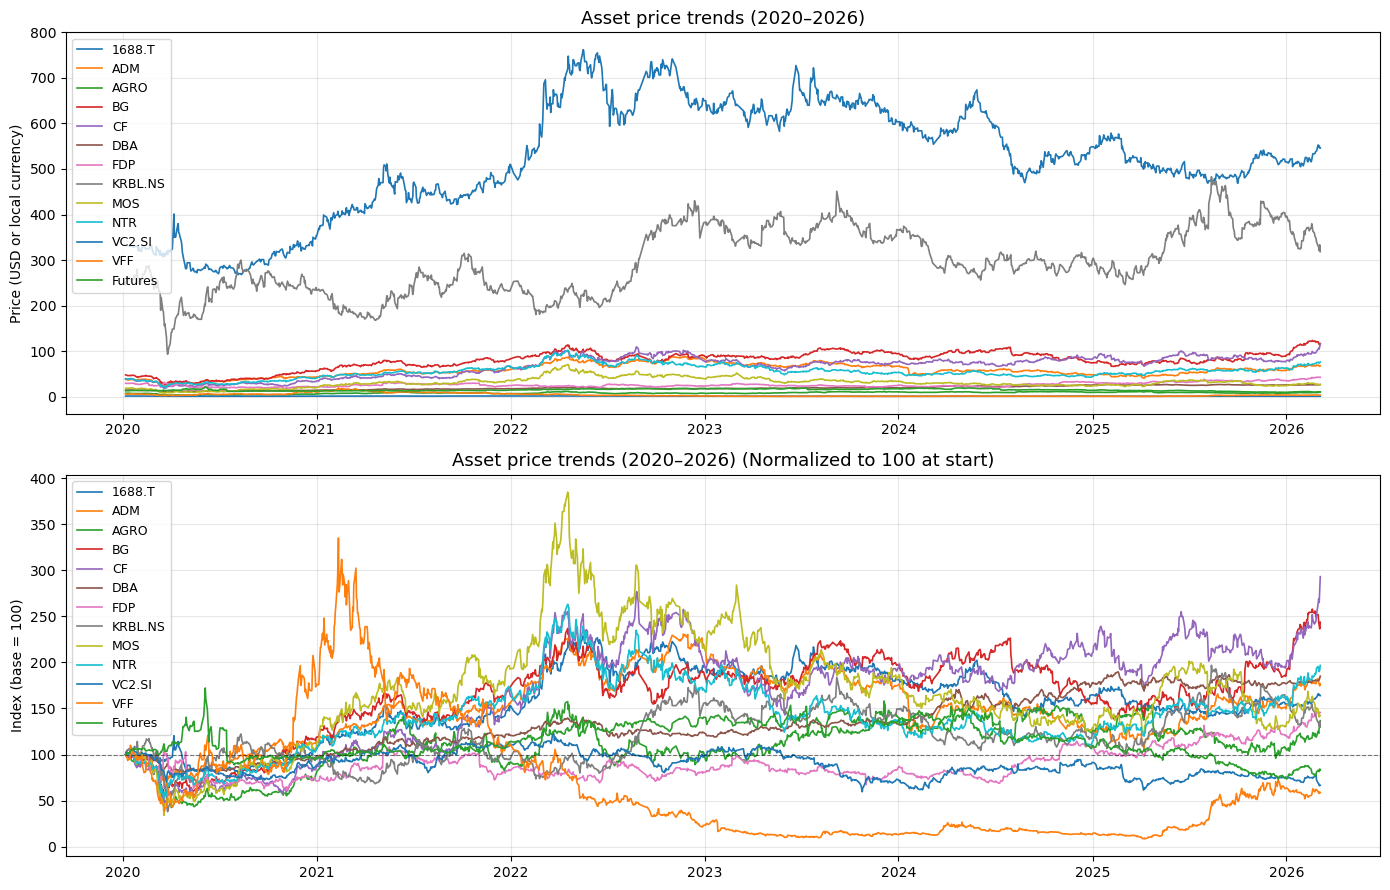

In [6]:
def price_visualization(df: pd.DataFrame, title: str = "Asset price trends (2020–2026)") -> None:
    # Normalize all prices to 100 at the start of the period for comparison.
    first_valid = df.apply(lambda col: col[col.notna()].iloc[0])
    df_norm = df / first_valid * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # --- Plot 1: Raw prices ---
    for col in df.columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1.2)
    axes[0].set_title(title, fontsize=13)
    axes[0].set_ylabel('Price (USD or local currency)')
    axes[0].legend(fontsize=9)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # --- Plot 2: Normalized prices (rebased to 100) ---
    for col in df_norm.columns:
        axes[1].plot(df_norm.index, df_norm[col], label=col, linewidth=1.2)
    title_norm = title + " (Normalized to 100 at start)"
    axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title(title_norm, fontsize=13)
    axes[1].set_ylabel('Index (base = 100)')
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

price_visualization(df)

---
## 3. Asset Screening — Correlation & Cointegration

Following Section 3.1 and Section 5.2 of Yang & Malik (2024), we screen assets using two criteria:

1. **Pearson correlation** — assets must move together (high positive correlation with the anchor)
2. **Engle-Granger cointegration test** — the *spread* between log-prices must be stationary (mean-reverting)

We use only the **formation period** (2020–2022) for screening to avoid any look-ahead bias.
This part aim to determine which assets should be included within the trading bucket.

Here are the steps we have to follow:
- Split the data into formation data and trading data
- Calculate the correlation and cointegration between assets
- Select assets above threshold (strong correlations, high cointegration) and drop assets with low correlation/cointegration relationships (kept asset are included in the `participating_asset`)
- Filter the data to only participating assets

In [7]:
# ==========================
# TRAIN / TEST SPLIT
# ==========================
# Formation period: used to compute screening statistics, thresholds, covariances.
# Trading period:   out-of-sample backtesting — never seen during calibration.
# Both periods use the full asset universe (ALL_ASSETS) — screening happens next.

df_formation = df.loc[FORMATION_START:FORMATION_END].copy()
df_trading   = df.loc[TRADING_START:TRADING_END].copy()

ALL_ASSETS = df.columns.tolist()

**Person correlation**

We examine correlation using Pearson’s correlation coefficient, which ranges between $[−1,1]$. The higher the absolute value of the coefficient, the stronger the association between the two variables. A coefficient of $−1$ represents an absolute negative association, $1$ represents an absolute positive association, and $0$ indicates no association between datasets

We compute the Pearson correlation between all pais of log-prices. To select assets we define a threshold : `CORR_THRESHOLD`, which is the minimum acceptable **absolute** correlation with the `ANCHOR` (we compute absolute correlation not to penalise negative but strong correlations). This threshold is set at 40%.

In [8]:
# ===========================
# PEARSON CORRELATION (Formation period)
# ===========================

CORR_THRESHOLD = 0.40   # minimum acceptable correlation with the anchor

# compute log prices and correlation matrix
log_prices_form = np.log(df_formation[ALL_ASSETS])
corr_matrix = log_prices_form.corr()

print("Pearson Correlation Matrix (log-prices, formation period — all assets):")
print(corr_matrix.round(4))
print()


Pearson Correlation Matrix (log-prices, formation period — all assets):
         1688.T     ADM    AGRO      BG      CF     DBA    FDP  KRBL.NS  \
1688.T   1.0000  0.9533  0.7998  0.9231  0.9605  0.9477 0.2100   0.5187   
ADM      0.9533  1.0000  0.8037  0.9564  0.9647  0.9340 0.1788   0.5587   
AGRO     0.7998  0.8037  1.0000  0.9015  0.7972  0.9002 0.3904   0.3974   
BG       0.9231  0.9564  0.9015  1.0000  0.9249  0.9680 0.2484   0.4829   
CF       0.9605  0.9647  0.7972  0.9249  1.0000  0.9321 0.1958   0.5307   
DBA      0.9477  0.9340  0.9002  0.9680  0.9321  1.0000 0.2735   0.4950   
FDP      0.2100  0.1788  0.3904  0.2484  0.1958  0.2735 1.0000   0.0132   
KRBL.NS  0.5187  0.5587  0.3974  0.4829  0.5307  0.4950 0.0132   1.0000   
MOS      0.9039  0.9579  0.8295  0.9454  0.9443  0.9160 0.2617   0.4027   
NTR      0.8943  0.9357  0.7805  0.9099  0.9368  0.8903 0.2637   0.3490   
VC2.SI   0.3475  0.3997  0.3931  0.4220  0.4045  0.4052 0.5092  -0.1262   
VFF     -0.5964 -0.4866 -0.2

In [9]:
# Correlation of each asset with the Futures anchor
corr_with_anchor = corr_matrix[ANCHOR].drop(ANCHOR).sort_values(ascending=False)

# Assets that pass the correlation threshold
assets_pass_corr = corr_with_anchor[np.abs(corr_with_anchor) >= CORR_THRESHOLD].index.tolist()
assets_pass_corr = [ANCHOR] + assets_pass_corr   # include the anchor
print(f"Assets passing correlation screening: {assets_pass_corr}")

Assets passing correlation screening: ['Futures', '1688.T', 'CF', 'ADM', 'DBA', 'NTR', 'BG', 'MOS', 'KRBL.NS', 'VFF']


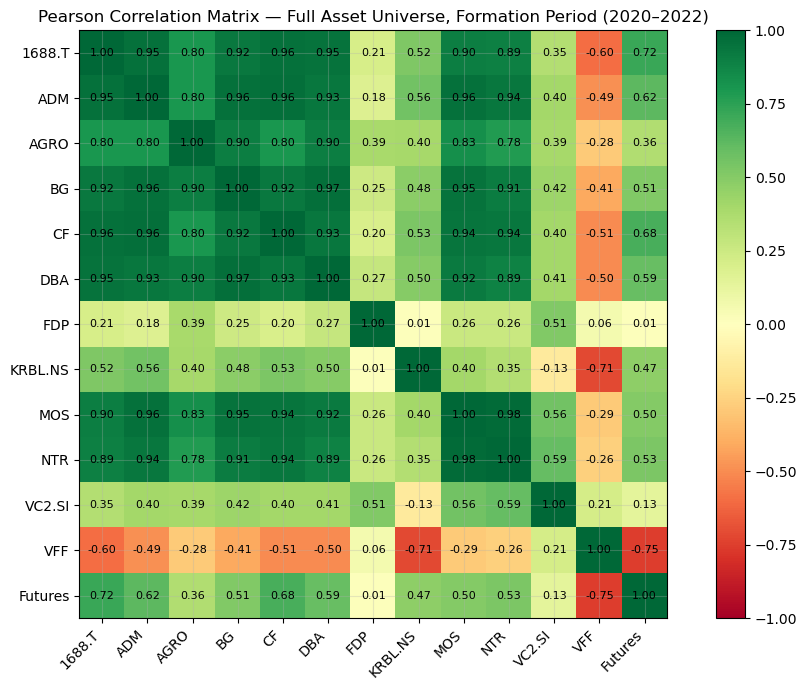

In [10]:
# Visualize the correlation matrix (full universe)
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=8)
ax.set_title('Pearson Correlation Matrix — Full Asset Universe, Formation Period (2020–2022)', fontsize=12)
plt.tight_layout()
plt.show()

**Engle-Granger Cointegration Test**

We test cointegration test only on assets that passed the correlation filter againt the `ANCHOR`. This is consistent with with Yang & Malik (2024) that state that both conditions must be met.

According to the article, wto assets $P_i$ and $P_j$ are **cointegrated** if, despite both being non-stationary, a linear combination of them is stationary (mean-reverting). This is the main assumption behind pair trading: temporary divergences will always revert to a long-run equilibrium.

This cointegration can be computed by folling two steps:

**Step 1 — OLS Regression**

We estimate the long-run relationship between log-prices:

$$\text{spread}_t = \log(P_{j,t}) - \hat{\beta} \cdot \log(P_{i,t}) - \hat{\alpha}$$

where $\hat{\beta}$ and $\hat{\alpha}$ are estimated by OLS on the formation period.
If the pair is cointegrated, this spread should be **stationary**.

**Step 2 — ADF (Augmented Dickey-Fuller) Test**

We apply the ADF test to the spread to verify stationarity:

- $H_0$: the spread has a unit root (non-stationary, no cointegration)
- $H_1$: the spread is stationary (cointegration confirmed)

We reject $H_0$ and conclude cointegration if $p\text{-value} < 0.10$.
We set `COINTEGRATION_THRESHOLD = 0.10`.

In [11]:
# ==========================
# ENGLE-GRANGER COINTEGRATION TEST (Formation period)
# ==========================

COINTEGRATION_THRESHOLD = 0.50

log_prices_corr = np.log(df_formation[assets_pass_corr])

coint_results = []
cointegrated_pairs = []

# x is always the Futures anchor
x = log_prices_corr[ANCHOR].values

for asset in assets_pass_corr:
    if asset == ANCHOR:
        continue   # skip the anchor itself

    y = log_prices_corr[asset].values

    # OLS regression to get the cointegration residual
    reg    = linregress(x, y)
    spread = y - (reg.slope * x + reg.intercept)

    # ADF test
    adf_result = adfuller(spread, regression='ct')
    pvalue     = adf_result[1]
    adf_stat   = adf_result[0]

    is_cointegrated = (pvalue < COINTEGRATION_THRESHOLD)
    coint_results.append({
        'Pair'      : f'{ANCHOR} / {asset}',
        'ADF Stat'  : round(adf_stat, 4),
        'p-value'   : round(pvalue, 4),
        'OLS slope' : round(reg.slope, 4),
        'Cointegrated' : 'passed' if is_cointegrated else 'rejected',
    })
    if is_cointegrated:
        cointegrated_pairs.append((pvalue, asset))

coint_df = pd.DataFrame(coint_results)
print("Engle-Granger Cointegration Test")
print(coint_df.to_string(index=False))
print()
print(f"Assets cointegrated with Futures (p < {COINTEGRATION_THRESHOLD}): "
      f"{[a for _, a in cointegrated_pairs]}")

Engle-Granger Cointegration Test
             Pair  ADF Stat  p-value  OLS slope Cointegrated
 Futures / 1688.T   -1.8318   0.6892     1.7120     rejected
     Futures / CF   -2.4547   0.3509     2.2885       passed
    Futures / ADM   -1.9991   0.6019     1.4214     rejected
    Futures / DBA   -2.8511   0.1788     0.6995       passed
    Futures / NTR   -1.5559   0.8092     1.3400     rejected
     Futures / BG   -1.8822   0.6638     1.3864     rejected
    Futures / MOS   -1.5176   0.8230     1.8374     rejected
Futures / KRBL.NS   -3.2310   0.0784     0.9314       passed
    Futures / VFF   -2.2264   0.4750    -5.4370       passed

Assets cointegrated with Futures (p < 0.5): ['CF', 'DBA', 'KRBL.NS', 'VFF']


**Trading Bucket**

Now that the asset selection has been completed.

In [12]:
# ==========================
# TRADING BUCKET
# ==========================

# Sort cointegrated assets by p-value (best cointegration first) and keep top 5
cointegrated_pairs.sort()   # sorts by pvalue automatically
cointegrated_equities = [asset for (_, asset) in cointegrated_pairs][:5]

# Build the bucket: anchor + best cointegrated equities
BUCKET = [ANCHOR] + cointegrated_equities

if len(BUCKET) < 2:
    print("Warning: no cointegrated pairs found — consider widening COINTEGRATION_THRESHOLD.")
else:
    print(f"Trading bucket of {len(BUCKET)} assets : {BUCKET}")

# Create a lookup dictionary: index -> asset name (mirrors the prof's code structure)
lookup = {str(i): asset for i, asset in enumerate(BUCKET)}
print(lookup)

Trading bucket of 5 assets : ['Futures', 'KRBL.NS', 'DBA', 'CF', 'VFF']
{'0': 'Futures', '1': 'KRBL.NS', '2': 'DBA', '3': 'CF', '4': 'VFF'}


---
## 4. Hist Analysis

The next step is the Hist Analysis step. 

### 4.1 Spread Computation & Z-Score Signaling



Following Section 3.2 of Yang & Malik (2024), we compute the **log-price spread** between each pair of assets and normalize it using the **z-score**.  
Trading signals are generated when the z-score exceeds the `OPEN_THRESHOLD` (open position) or falls below `CLOSE_THRESHOLD` (close position).

In [13]:
# ==========================
# SPREAD COMPUTATION (adapted from professor's arbitrage_trade function)
# ========================= 
# For each pair (i, j), the spread is computed as the OLS residual in log space:
#   spread(i,j,t) = log(P_j,t) - [beta * log(P_i,t) + intercept]
# This is equivalent to the log-price difference after removing a linear trend.
# We fit the OLS on the FORMATION period and apply it to ALL data (form + trade).

def compute_spreads(df_ref, df_all, assets, dofuller=True):
    """
    Compute pairwise log-price spreads (OLS residuals) for all asset pairs.
    OLS is fitted on df_ref (formation), applied on df_all (all data).
    Only keeps pairs that pass the Engle-Granger cointegration test (p < 0.10)
    if dofuller=True.

    Returns:
        spreads_form : DataFrame of spreads over formation period
        spreads_trade: DataFrame of spreads over trading period
        spread_meta  : dict with OLS parameters per pair
    """
    log_ref = np.log(df_ref[assets])
    log_all = np.log(df_all[assets])

    spreads_form  = pd.DataFrame(index=df_ref.index)
    spreads_all   = pd.DataFrame(index=df_all.index)
    spread_meta   = {}

    cols = assets
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            a_i, a_j = cols[i], cols[j]
            xi = log_ref[a_i].values
            yi = log_ref[a_j].values

            # OLS fit on formation data (same as prof's code: linregress)
            reg = linregress(xi, yi)

            # Compute spread on formation period
            sp_form = log_ref[a_j] - (reg.slope * log_ref[a_i] + reg.intercept)

            # ADF test on formation spread (as in prof's code)
            if dofuller:
                _, pval, _, _, _, _ = adfuller(sp_form.dropna(), regression='ct')
                if pval >= 0.10:
                    continue   # skip non-stationary spreads

            # Key: 's_{j_idx}_{i_idx}' — mirrors prof's naming convention
            idx_i = str(assets.index(a_i))
            idx_j = str(assets.index(a_j))
            key   = f's_{idx_j}_{idx_i}'

            spreads_form[key]  = sp_form.values
            # Apply the SAME OLS parameters to the full dataset (no look-ahead bias)
            sp_all = log_all[a_j] - (reg.slope * log_all[a_i] + reg.intercept)
            spreads_all[key]   = sp_all.values
            spread_meta[key]   = {'slope': reg.slope, 'intercept': reg.intercept,
                                   'asset_i': a_i, 'asset_j': a_j,
                                   'idx_i': idx_i, 'idx_j': idx_j}

    return spreads_form, spreads_all, spread_meta


spreads_form, spreads_all, spread_meta = compute_spreads(
    df_formation, df, BUCKET, dofuller=True
)

print(f"Number of valid (cointegrated) spreads: {len(spreads_form.columns)}")
print("Spread keys:", list(spreads_form.columns))
print()
for k, meta in spread_meta.items():
    print(f"  {k} → {meta['asset_j']} vs {meta['asset_i']}  "
          f"(slope={meta['slope']:.4f}, intercept={meta['intercept']:.4f})")

Number of valid (cointegrated) spreads: 1
Spread keys: ['s_1_0']

  s_1_0 → KRBL.NS vs Futures  (slope=0.9314, intercept=3.0606)


In [14]:
# =============================================================================
# Z-SCORE NORMALIZATION (Formation period parameters)
# =============================================================================
# The z-score is computed using the FORMATION period mean and std.
# This ensures no look-ahead bias: normalization parameters come from
# historical data only.
#
# As in Yang & Malik (2024) Section 3.2.2:
#   z-score(t) = (spread(t) - mean_formation) / std_formation
#
# NOTE: The open/close thresholds (OPEN_THRESHOLD * std, CLOSE_THRESHOLD * std)
# are NOT applied here. They will be set after the grid search in Section 4.5
# and added to spread_stats by cell-recompute-stats.

spread_stats = {}   # stores mean and std from the formation period
zscores_all  = pd.DataFrame(index=df.index)

for k in spreads_form.columns:
    mu  = spreads_form[k].mean()
    std = spreads_form[k].std(ddof=0)
    # Store only mean and std here — thresholds added after grid search
    spread_stats[k] = {'mean': mu, 'std': std}
    # Normalize the full-period spread using formation parameters
    zscores_all[k] = (spreads_all[k] - mu) / std

# Restrict z-scores to each period
zscores_form  = zscores_all.loc[FORMATION_START:FORMATION_END]
zscores_trade = zscores_all.loc[TRADING_START:TRADING_END]

print('Z-scores computed (formation parameters: mean and std only).')
print('Thresholds will be added after the grid search.')
print()
stats_df = pd.DataFrame(spread_stats).T
stats_df.index.name = 'Spread'
print(stats_df.round(6))


Z-scores computed (formation parameters: mean and std only).
Thresholds will be added after the grid search.

          mean    std
Spread               
s_1_0  -0.0000 0.2365


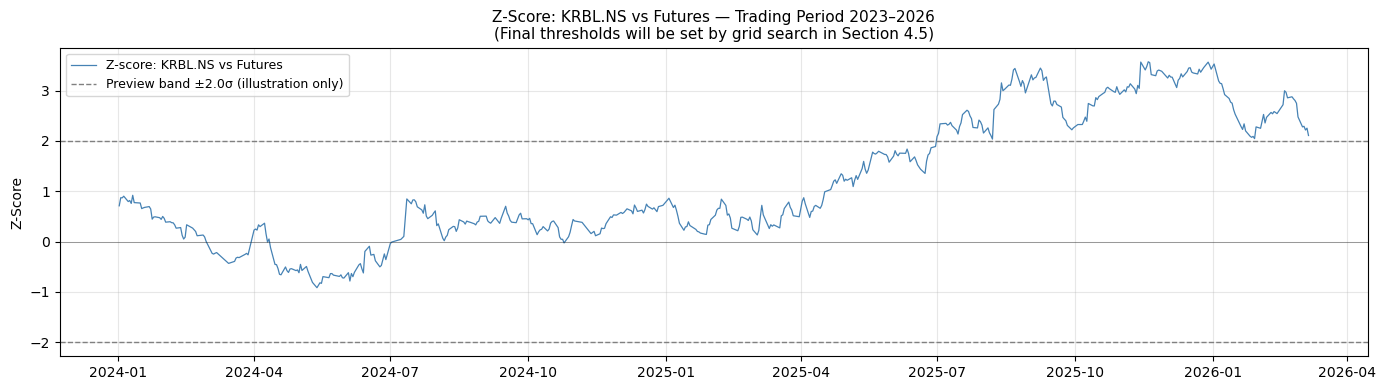

In [15]:
# =============================================================================
# VISUALIZE SPREADS & Z-SCORES (Trading period)
# =============================================================================
# This plot shows the z-score dynamics during the trading period.
# The dashed lines represent a preliminary ±2 std band for illustration only.
# The actual trading thresholds will be determined by the grid search (Section 4.5)
# and applied in the simulation.

PREVIEW_BAND = 2.0   # preliminary band for visualization only (not used in trading)

n_spreads = len(spreads_form.columns)
if n_spreads == 0:
    print('No valid spreads to plot.')
else:
    fig, axes = plt.subplots(n_spreads, 1, figsize=(14, 4 * n_spreads), squeeze=False)

    for idx, k in enumerate(spreads_form.columns):
        ax   = axes[idx][0]
        meta = spread_meta[k]
        label = f"{meta['asset_j']} vs {meta['asset_i']}"
        std   = spread_stats[k]['std']

        ax.plot(zscores_trade.index, zscores_trade[k],
                label=f'Z-score: {label}', linewidth=0.9, color='steelblue')
        ax.axhline( PREVIEW_BAND, color='gray', linestyle='--', linewidth=1.0,
                    label=f'Preview band ±{PREVIEW_BAND}σ (illustration only)')
        ax.axhline(-PREVIEW_BAND, color='gray', linestyle='--', linewidth=1.0)
        ax.axhline(0, color='black', linestyle='-', linewidth=0.6, alpha=0.4)

        ax.set_title(f'Z-Score: {label} — Trading Period 2023–2026\n'
                     f'(Final thresholds will be set by grid search in Section 4.5)',
                     fontsize=11)
        ax.set_ylabel('Z-Score')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.show()


---
### 4.5 Grid Search for Optimal Thresholds

Yang & Malik (2024) **Section 5.3 and Figure 5** perform a grid search over `OPEN_THRESHOLD` and `CLOSE_THRESHOLD` on the **formation period** to find the most profitable combination before applying it out-of-sample.

> *"We conduct a grid search for the thresholds that are likely to generate high profitability [...] A darker shade means better profit for the open_threshold / close_threshold combination."* — Yang & Malik (2024), p.14

**Important adaptation note:** Table 3 of the paper reports optimal thresholds of **7 std-devs (open) / 6 std-devs (close)** for 60-minute cryptocurrency data. These values cannot be transposed directly to **daily equity data**, which exhibits significantly higher inter-period volatility. At daily frequency, a z-score of 7σ is almost never reached, resulting in zero trades. The grid search below determines the empirically optimal thresholds for our daily rice dataset.

In [16]:
# =============================================================================
# GRID SEARCH FOR OPTIMAL THRESHOLDS (Figure 5 analog — Yang & Malik 2024)
# =============================================================================
# We search over a grid of (OPEN_THRESHOLD, CLOSE_THRESHOLD) combinations
# and evaluate the annualized profitability of a simplified OTT on the
# FORMATION PERIOD only (2020-2022).
#
# A lightweight simulation (without Gurobi) is used here for speed:
# equal-weight allocation when a signal is triggered. The relative ranking
# of threshold combinations is robust to this simplification.
# The best combination is then used for the full Gurobi simulation.

import itertools

def simple_backtest(spreads_f, zscores_f, prices_f, open_thr, close_thr, orig=10_000, tc=0.001):
    """
    Lightweight equal-weight pair trading simulation on formation data.
    Used exclusively for grid search (no Gurobi — fast evaluation).

    Returns: annualized total P&L as a fraction of starting capital.
    """
    T = len(spreads_f)
    if T < 10:
        return 0.0

    total_pnl = 0.0
    n_trades  = 0
    open_pos  = {k: None for k in spreads_f.columns}  # None or (open_t, direction)

    for t in range(1, T):
        for k in spreads_f.columns:
            z     = zscores_f[k].iloc[t]
            sigma = spreads_f[k].std()
            open_threshold_val  = open_thr  * sigma
            close_threshold_val = close_thr * sigma

            # --- Close open position ---
            if open_pos[k] is not None:
                open_t, direction, p_long_open, p_short_open = open_pos[k]
                if abs(z) < close_threshold_val:
                    # Get current prices
                    keys   = k.split('_')      # k = 's_{j}_{i}'
                    idx_j  = int(keys[1])
                    idx_i  = int(keys[2])
                    col_j  = spreads_f.columns.get_loc(k)   # not needed here
                    asset_j = BUCKET[idx_j]
                    asset_i = BUCKET[idx_i]

                    p_long_close  = prices_f[asset_j if direction == 'long_j' else asset_i].iloc[t]
                    p_short_close = prices_f[asset_i if direction == 'long_j' else asset_j].iloc[t]

                    # Profit = (close_long / open_long - 1) - (close_short / open_short - 1)
                    ret_long  = (p_long_close  * (1 - tc)) / (p_long_open  * (1 + tc)) - 1
                    ret_short = (p_short_close * (1 + tc)) / (p_short_open * (1 - tc)) - 1
                    pnl = 0.5 * ret_long - 0.5 * ret_short   # equal weight
                    total_pnl += pnl
                    n_trades  += 1
                    open_pos[k] = None

            # --- Open new position ---
            elif abs(z) > open_threshold_val:
                keys    = k.split('_')
                idx_j   = int(keys[1])
                idx_i   = int(keys[2])
                asset_j = BUCKET[idx_j]
                asset_i = BUCKET[idx_i]

                if z > 0:
                    # j overpriced vs i: short j, long i
                    direction    = 'long_i'
                    p_long_open  = prices_f[asset_i].iloc[t]
                    p_short_open = prices_f[asset_j].iloc[t]
                else:
                    # i overpriced vs j: short i, long j
                    direction    = 'long_j'
                    p_long_open  = prices_f[asset_j].iloc[t]
                    p_short_open = prices_f[asset_i].iloc[t]

                open_pos[k] = (t, direction, p_long_open, p_short_open)

    # Annualize: formation period = ~756 trading days (3 years)
    trading_days = T
    ann_pnl = (1 + total_pnl) ** (252 / trading_days) - 1 if trading_days > 0 else 0
    return ann_pnl


# --- Define the grid ---
# We explore a range appropriate for daily data (much lower than paper's crypto values)
open_thresholds  = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
close_thresholds = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

# Only test combinations where open > close (required by design)
grid_results = {}

# Use formation period prices and z-scores
prices_form_df = df_formation[BUCKET]

print("Running grid search on formation period (2020–2022)...")
print(f"Grid size: {len(open_thresholds)} × {len(close_thresholds)} = "
      f"{len(open_thresholds)*len(close_thresholds)} combinations")
print()

for ot, ct in itertools.product(open_thresholds, close_thresholds):
    if ct >= ot:
        continue   # close threshold must be strictly below open threshold
    pnl = simple_backtest(spreads_form, zscores_form, prices_form_df, ot, ct)
    grid_results[(ot, ct)] = pnl

# Build results DataFrame
grid_df = pd.DataFrame([
    {'OPEN_THRESHOLD': ot, 'CLOSE_THRESHOLD': ct, 'Ann. Return': pnl}
    for (ot, ct), pnl in grid_results.items()
])
grid_df = grid_df.sort_values('Ann. Return', ascending=False).reset_index(drop=True)

print("Top 10 threshold combinations (by annualized return on formation period):")
print(grid_df.head(10).to_string(index=False))

# --- Best combination ---
best_ot = grid_df.iloc[0]['OPEN_THRESHOLD']
best_ct = grid_df.iloc[0]['CLOSE_THRESHOLD']
best_ret = grid_df.iloc[0]['Ann. Return']

print(f"\n>>> Best combination: OPEN = {best_ot}σ, CLOSE = {best_ct}σ "
      f"(formation ann. return = {best_ret*100:.2f}%)")
print(">>> These values will now replace the initial parameters for the full simulation.")

# --- Update global parameters ---
OPEN_THRESHOLD  = best_ot
CLOSE_THRESHOLD = best_ct

print(f"\nParameters updated: OPEN_THRESHOLD = {OPEN_THRESHOLD}, "
      f"CLOSE_THRESHOLD = {CLOSE_THRESHOLD}")

Running grid search on formation period (2020–2022)...
Grid size: 7 × 6 = 42 combinations

Top 10 threshold combinations (by annualized return on formation period):
 OPEN_THRESHOLD  CLOSE_THRESHOLD  Ann. Return
         2.5000           2.0000       0.1949
         2.0000           1.5000       0.1937
         4.0000           0.2500       0.1887
         3.0000           1.0000       0.1885
         1.5000           0.5000       0.1862
         3.0000           1.5000       0.1860
         2.5000           1.5000       0.1850
         3.5000           0.7500       0.1812
         3.0000           0.7500       0.1803
         4.0000           0.5000       0.1800

>>> Best combination: OPEN = 2.5σ, CLOSE = 2.0σ (formation ann. return = 19.49%)
>>> These values will now replace the initial parameters for the full simulation.

Parameters updated: OPEN_THRESHOLD = 2.5, CLOSE_THRESHOLD = 2.0


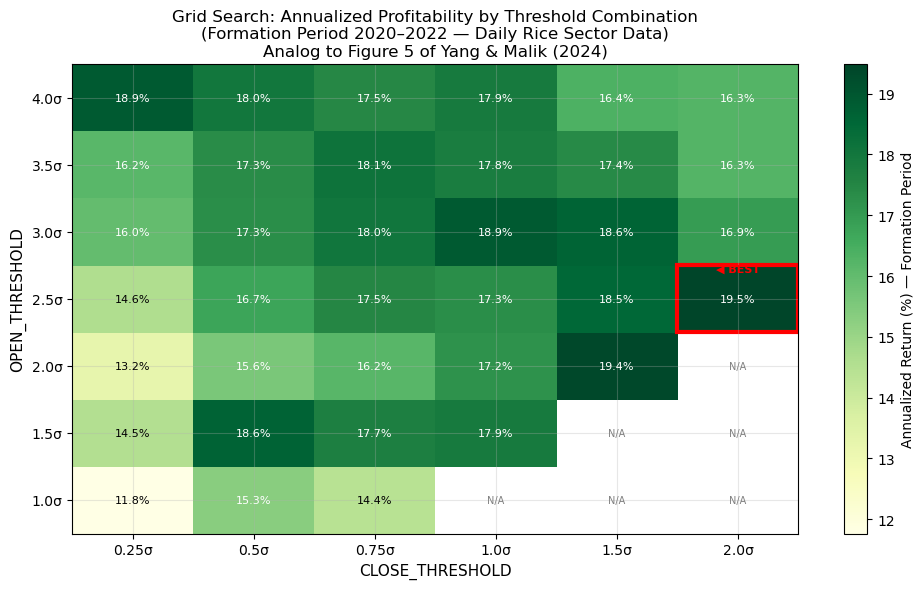

Best thresholds selected: OPEN = 2.5σ, CLOSE = 2.0σ

Note: Unlike Table 3 of Yang & Malik (2024) which reports 7σ/6σ for 60-min
crypto data, daily equity data requires much lower thresholds due to higher
inter-period price variability. The grid search empirically confirms this.


In [17]:
# =============================================================================
# GRID SEARCH HEATMAP (Figure 5 of Yang & Malik 2024)
# =============================================================================
# Visualize the annualized profitability for each (OPEN, CLOSE) combination.
# Darker = more profitable (same convention as Figure 5 in the paper).

# Pivot to matrix form for heatmap
heatmap_data = grid_df.pivot_table(
    index='OPEN_THRESHOLD', columns='CLOSE_THRESHOLD', values='Ann. Return'
)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap_data.values * 100, cmap='YlGn',
               aspect='auto', origin='lower')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Annualized Return (%) — Formation Period', fontsize=10)

# Axis labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels([f'{v}σ' for v in heatmap_data.columns])
ax.set_yticklabels([f'{v}σ' for v in heatmap_data.index])
ax.set_xlabel('CLOSE_THRESHOLD', fontsize=11)
ax.set_ylabel('OPEN_THRESHOLD',  fontsize=11)
ax.set_title(
    'Grid Search: Annualized Profitability by Threshold Combination\n'
    '(Formation Period 2020–2022 — Daily Rice Sector Data)\n'
    'Analog to Figure 5 of Yang & Malik (2024)',
    fontsize=12
)

# Annotate each cell with the return value
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val*100:.1f}%',
                    ha='center', va='center', fontsize=8,
                    color='black' if val < 0.15 else 'white')
        else:
            # Invalid combination (close >= open)
            ax.text(j, i, 'N/A', ha='center', va='center',
                    fontsize=7, color='gray')

# Highlight the best combination
best_col_idx = list(heatmap_data.columns).index(best_ct)
best_row_idx = list(heatmap_data.index).index(best_ot)
rect = plt.Rectangle(
    (best_col_idx - 0.5, best_row_idx - 0.5), 1, 1,
    linewidth=3, edgecolor='red', facecolor='none'
)
ax.add_patch(rect)
ax.text(best_col_idx, best_row_idx + 0.38, '◀ BEST',
        ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Best thresholds selected: OPEN = {best_ot}σ, CLOSE = {best_ct}σ")
print()
print("Note: Unlike Table 3 of Yang & Malik (2024) which reports 7σ/6σ for 60-min")
print("crypto data, daily equity data requires much lower thresholds due to higher")
print("inter-period price variability. The grid search empirically confirms this.")

spread_stats updated with optimal thresholds:
  OPEN_THRESHOLD  = 2.5σ
  CLOSE_THRESHOLD = 2.0σ

         std  open_thr  close_thr
s_1_0 0.2365    0.5912     0.4730



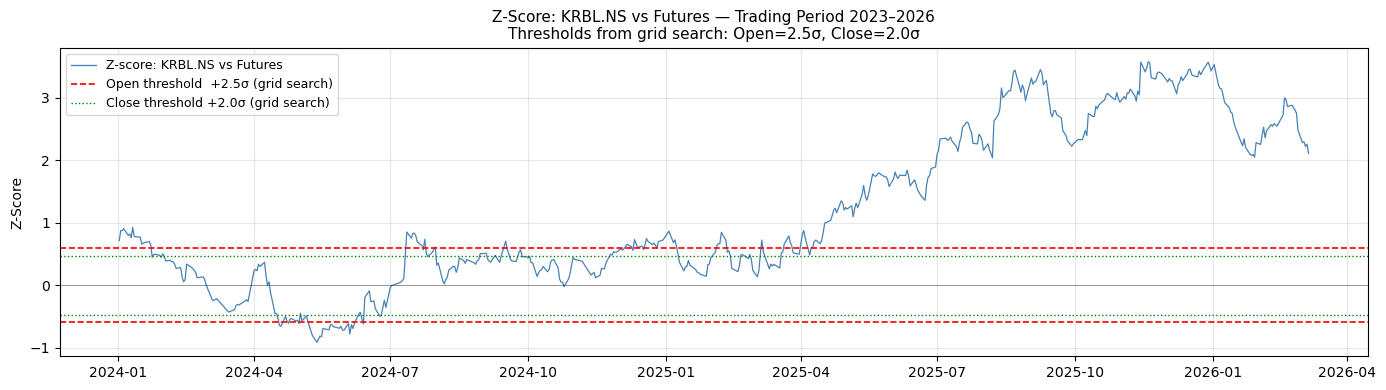

All downstream cells (Section 5 onward) will use these thresholds.


In [18]:
# =============================================================================
# APPLY OPTIMAL THRESHOLDS FROM GRID SEARCH TO SPREAD STATS
# =============================================================================
# Now that OPEN_THRESHOLD and CLOSE_THRESHOLD have been determined by the
# grid search, we add them to spread_stats. All downstream code (simulation,
# mean-reversion estimation, performance metrics) uses spread_stats['open_thr']
# and spread_stats['close_thr'] — so this is the single source of truth.

for k in spreads_form.columns:
    spread_stats[k]['open_thr']  = OPEN_THRESHOLD  * spread_stats[k]['std']
    spread_stats[k]['close_thr'] = CLOSE_THRESHOLD * spread_stats[k]['std']

print('spread_stats updated with optimal thresholds:')
print(f'  OPEN_THRESHOLD  = {OPEN_THRESHOLD}σ')
print(f'  CLOSE_THRESHOLD = {CLOSE_THRESHOLD}σ')
print()
print(pd.DataFrame(spread_stats).T[['std','open_thr','close_thr']].round(6))
print()

# --- Re-plot z-scores with the REAL thresholds (final version of the signal plot) ---
n_spreads = len(spreads_form.columns)
if n_spreads > 0:
    fig, axes = plt.subplots(n_spreads, 1, figsize=(14, 4 * n_spreads), squeeze=False)
    for idx, k in enumerate(spreads_form.columns):
        ax   = axes[idx][0]
        meta = spread_meta[k]
        label      = f"{meta['asset_j']} vs {meta['asset_i']}"
        open_thr   = spread_stats[k]['open_thr']
        close_thr  = spread_stats[k]['close_thr']

        ax.plot(zscores_trade.index, zscores_trade[k],
                label=f'Z-score: {label}', linewidth=0.9, color='steelblue')
        ax.axhline( open_thr,  color='red',   linestyle='--', linewidth=1.2,
                    label=f'Open threshold  +{OPEN_THRESHOLD}σ (grid search)')
        ax.axhline(-open_thr,  color='red',   linestyle='--', linewidth=1.2)
        ax.axhline( close_thr, color='green', linestyle=':',  linewidth=1.0,
                    label=f'Close threshold +{CLOSE_THRESHOLD}σ (grid search)')
        ax.axhline(-close_thr, color='green', linestyle=':',  linewidth=1.0)
        ax.axhline(0, color='black', linestyle='-', linewidth=0.6, alpha=0.4)
        ax.set_title(f'Z-Score: {label} — Trading Period 2023–2026\n'
                     f'Thresholds from grid search: Open={OPEN_THRESHOLD}σ, Close={CLOSE_THRESHOLD}σ',
                     fontsize=11)
        ax.set_ylabel('Z-Score')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.show()

print('All downstream cells (Section 5 onward) will use these thresholds.')


---
## 5. Historical Analysis — Expected Returns & Risk

Before the optimizer can allocate weights, it needs two inputs estimated from the **formation period** (Section 3.3 of Yang & Malik 2024):

- **Expected returns** per asset: mean log-return × expected mean-reversion time
- **Expected risk** per pair: pairwise covariance matrix × expected mean-reversion time

These are computed by `sigma3` and `hist_analysis` in the professor's code.

In [19]:
# =============================================================================
# EXPECTED RETURNS (adapted from get_expected_returns in prof's code)
# =============================================================================
# Compute the mean daily log-return for each asset over the formation period.
# ret_vec[i] = E[log(P_{t+1}/P_t)] for asset i

log_returns_form = np.log(df_formation[BUCKET]).diff().dropna()
ret_vec = log_returns_form.mean()   # mean log-return per asset

print("Mean daily log-returns (formation period):")
print(ret_vec.to_frame('Mean log-return').round(6))

Mean daily log-returns (formation period):
         Mean log-return
Futures           0.0003
KRBL.NS           0.0004
DBA               0.0003
CF                0.0007
VFF              -0.0021


In [20]:
# =============================================================================
# PAIRWISE COVARIANCE MATRICES (adapted from pairwise_cov_matrices in prof's code)
# =============================================================================
# For each cointegrated pair, compute the 2x2 covariance matrix of log-returns.
# This is used in the risk part of the Gurobi objective (Eq. 2 of the paper).

def compute_cov_matrices(df_form, assets, spread_keys, spread_meta):
    """
    Compute pairwise 2x2 log-return covariance matrices for all valid pairs.
    Returns a dict {spread_key: pd.DataFrame (2x2 covariance matrix)}.
    """
    log_ret = np.log(df_form[assets]).diff().dropna()
    cov_matrices = {}

    for k in spread_keys:
        meta = spread_meta[k]
        a_i, a_j = meta['asset_i'], meta['asset_j']
        pair_ret = log_ret[[a_i, a_j]].dropna()
        cov = pair_ret.cov()   # 2x2 covariance matrix
        cov_matrices[k] = cov

    return cov_matrices

cov_matrices = compute_cov_matrices(df_formation, BUCKET, list(spreads_form.columns), spread_meta)

print("Pairwise covariance matrices (log-returns, formation period):")
for k, cov in cov_matrices.items():
    meta = spread_meta[k]
    print(f"\n  {k} ({meta['asset_j']} vs {meta['asset_i']}):")
    print(cov.round(8).to_string())

Pairwise covariance matrices (log-returns, formation period):

  s_1_0 (KRBL.NS vs Futures):
         Futures  KRBL.NS
Futures   0.0004   0.0000
KRBL.NS   0.0000   0.0011


In [21]:
# Requires: spread_stats must have 'open_thr' and 'close_thr' keys
# (set by cell-recompute-stats after grid search — run cells in order).
assert 'open_thr' in list(spread_stats.values())[0], \
    'ERROR: Run cell-recompute-stats (Section 4.5) before this cell.'

# =============================================================================
# MEAN-REVERSION TIME (adapted from get_expected_time_to_mean in prof's code)
# =============================================================================
# The expected mean-reversion time is the average number of days it takes
# for the spread to revert from the open threshold to the close threshold.
# This is estimated on the FORMATION period (Algorithm 1 line 1 in the paper).

def estimate_mean_reversion_time(spreads_form, zscores_form, spread_stats):
    """
    For each spread, simulate when positions would have been opened and closed
    during the formation period, and compute the average holding duration.
    Returns a Series {spread_key: mean_reversion_time_in_days}.
    """
    mr_times = {}
    for k in spreads_form.columns:
        open_thr  = spread_stats[k]['open_thr']
        close_thr = spread_stats[k]['close_thr']
        z         = zscores_form[k].values

        durations = []
        in_position = False
        open_day    = 0

        for t in range(len(z)):
            if not in_position and abs(z[t]) > open_thr:
                in_position = True
                open_day    = t
            elif in_position and abs(z[t]) < close_thr:
                durations.append(t - open_day)
                in_position = False

        mr_times[k] = np.mean(durations) if durations else 1.0  # default 1 day

    return pd.Series(mr_times)


# Use z-scores computed on formation data
zscores_form = pd.DataFrame(index=df_formation.index)
for k in spreads_form.columns:
    mu  = spread_stats[k]['mean']
    std = spread_stats[k]['std']
    zscores_form[k] = (spreads_form[k] - mu) / std

time_to_mean = estimate_mean_reversion_time(
    spreads_form, zscores_form, spread_stats
)

print("Estimated mean-reversion time (days, formation period):")
print(time_to_mean.to_frame('Mean reversion time (days)').round(2))

Estimated mean-reversion time (days, formation period):
       Mean reversion time (days)
s_1_0                     26.2600


In [22]:
# =============================================================================
# EXPECTED PROFIT & EXPECTED RISK (EP and COV from Section 3.3 of the paper)
# =============================================================================
# expected_returns[k] = [ret_i * mr_time, ret_j * mr_time]  (with tx cost deducted)
# expected_risk[k]    = cov_matrix[k] * mr_time

expected_returns = {}   # dict: spread_key → [EP_asset_i, EP_asset_j]
expected_risk    = {}   # dict: spread_key → 2x2 DataFrame

for k in spreads_form.columns:
    meta = spread_meta[k]
    a_i, a_j = meta['asset_i'], meta['asset_j']
    mr = time_to_mean[k]

    ri = ret_vec[a_i]
    rj = ret_vec[a_j]

    # With transaction cost (as in prof's code)
    ep_i = ri * mr - TX_COST * abs(ri * mr)
    ep_j = rj * mr - TX_COST * abs(rj * mr)

    expected_returns[k] = [ep_i, ep_j]   # index 0 → asset_i, index 1 → asset_j
    expected_risk[k]    = cov_matrices[k] * mr

print("Expected returns (EP) per pair [asset_i, asset_j]:")
for k, ep in expected_returns.items():
    meta = spread_meta[k]
    print(f"  {k} ({meta['asset_i']}, {meta['asset_j']}): {[round(v,6) for v in ep]}")

print()
print("Expected risk (COV * mr) per pair:")
for k, er in expected_risk.items():
    meta = spread_meta[k]
    print(f"  {k} ({meta['asset_i']}, {meta['asset_j']}):")
    print(er.round(8).to_string())

Expected returns (EP) per pair [asset_i, asset_j]:
  s_1_0 (Futures, KRBL.NS): [0.008231, 0.011078]

Expected risk (COV * mr) per pair:
  s_1_0 (Futures, KRBL.NS):
         Futures  KRBL.NS
Futures   0.0108   0.0001
KRBL.NS   0.0001   0.0281


---
## 6. Gurobi Bi-Objective Optimization

This section implements the **Optimal Trading Technique (OTT)** optimizer from Yang & Malik (2024), Section 3.3.  
The Gurobi model solves **Equation (6)** of the paper: a bi-objective problem that maximizes expected profit while minimizing portfolio risk, subject to:
- Weight bounds (no leverage: weights ∈ [0,1] for longs, [−1,0] for shorts)
- Capital constraint (cannot invest more than available balance)
- Market-neutrality constraint (ETH/commodity bought = ETH/commodity sold)

In [23]:
# =============================================================================
# GUROBI OPTIMIZER — build_prob_cons
# (closely adapted from the professor's build_prob_cons function)
# =============================================================================
# Implements Equation (6) of Yang & Malik (2024):
#
#   max  sum_n [ W_n . (EP_n ⊙ [1,-1])' ] - lambda * sum_n [ W_n . COV_n . W_n' ]
#   s.t. 0 <= W_long <= 1,  -1 <= W_short <= 0       (weight bounds)
#        tw_c + sum(W_long) - sum(W_short) <= 1        (capital constraint)
#        -W_short * P_long * (1+tc) = W_long * P_short * (1-tc)  (market neutrality)

def build_optimizer(longs, shorts, prices_at_t, expected_returns, expected_risk,
                    trading_weights, spread_keys, lam, tc):
    """
    Build the Gurobi model for the bi-objective optimization.

    Parameters:
    -----------
    longs            : list of (spread_key, idx_str) for the long side
    shorts           : list of (spread_key, idx_str) for the short side
    prices_at_t      : dict {idx_str: price at current time t}
    expected_returns : dict {spread_key: [ep_i, ep_j]}
    expected_risk    : dict {spread_key: 2x2 cov DataFrame}
    trading_weights  : dict {idx_str: list of past weights (open positions)}
    spread_keys      : the spread keys that are currently being opened
    lam              : risk-aversion coefficient lambda
    tc               : boolean, whether to include transaction costs

    Returns:
    --------
    model : Gurobi Model
    lsws  : iterator of (long_var, short_var) pairs
    """
    model = gp.Model('portfolio')
    model.Params.OutputFlag = 0   # suppress Gurobi output

    # --- Decision variables ---
    # lw = long weight for each pair, sw = short weight for each pair
    lws = [model.addVar(name=f'l!{sk}!{li}', lb=0,  ub=1)  for (sk, li) in longs]
    sws = [model.addVar(name=f's!{sk}!{si}', lb=-1, ub=0)  for (sk, si) in shorts]
    model.update()

    # --- Objective Part 1: Expected return ---
    # For each pair, the long side contributes +EP and the short side contributes -EP
    obj_return = gp.LinExpr()
    for idx_pair, (sk, li) in enumerate(longs):
        meta = spread_meta[sk]
        # Determine which EP corresponds to the long and short asset
        ep_long  = expected_returns[sk][0] if li == meta['idx_i'] else expected_returns[sk][1]
        ep_short = expected_returns[sk][0] if shorts[idx_pair][1] == meta['idx_i'] else expected_returns[sk][1]
        obj_return += ep_long  * lws[idx_pair]
        obj_return += ep_short * sws[idx_pair]   # short EP enters negatively via weight sign

    # --- Objective Part 2: Portfolio risk (quadratic) ---
    # W_n . COV_n_modified . W_n'  where COV is modified to account for short positions
    obj_risk = gp.QuadExpr()
    for idx_pair, sk in enumerate(spread_keys):
        cov = expected_risk[sk].values   # 2x2 numpy array
        # Modify covariance for short positions (as in prof's code: negate off-diagonal)
        cov_mod = cov.copy()
        cov_mod[0, 1] = -cov_mod[0, 1]
        cov_mod[1, 0] = -cov_mod[1, 0]
        w = [lws[idx_pair], sws[idx_pair]]
        for a in range(2):
            for b in range(2):
                obj_risk += cov_mod[a, b] * w[a] * w[b]

    # --- Full objective: maximize (return - lambda * risk) ---
    model.setObjective(obj_return - lam * obj_risk, GRB.MAXIMIZE)

    # --- Constraint 1: Capital constraint (cannot invest more than available) ---
    all_idxs = set([li for (_, li) in longs] + [si for (_, si) in shorts])
    for idx_str in all_idxs:
        tw_sum = sum(trading_weights.get(idx_str, []))   # currently locked capital
        relevant_lws = [lws[i] for i, (_, li) in enumerate(longs)  if li == idx_str]
        relevant_sws = [sws[i] for i, (_, si) in enumerate(shorts) if si == idx_str]
        expr = tw_sum
        for v in relevant_lws:
            expr += (v * (1 + TX_COST) if tc else v)
        for v in relevant_sws:
            expr += (v * (1 - TX_COST) if tc else v)
        model.addConstr(expr <= 1, name=f'cap_{idx_str}')

    # --- Constraint 2: Market neutrality (commodity bought = commodity sold) ---
    # -W_short * P_long * (1+tc) = W_long * P_short * (1-tc)  [Equation 5 of paper]
    for idx_pair, (sk, li) in enumerate(longs):
        si     = shorts[idx_pair][1]
        p_long  = prices_at_t[li]
        p_short = prices_at_t[si]
        if tc:
            # Market neutrality with transaction costs
            model.addConstr(
                -sws[idx_pair] * (p_long * (1 + TX_COST)) / (p_short * (1 - TX_COST)) == lws[idx_pair],
                name=f'neutral_{sk}'
            )
        else:
            model.addConstr(
                -sws[idx_pair] * (p_long / p_short) == lws[idx_pair],
                name=f'neutral_{sk}'
            )

    return model, list(zip(lws, sws))


print("Gurobi optimizer function defined.")
print(f"Gurobi version: {gp.gurobi.version()}")

Gurobi optimizer function defined.
Gurobi version: (13, 0, 1)


---
## 7. Simulation & Backtesting

We now run the full simulation on the **out-of-sample trading period (2023–2026)**.  
At each time step:
1. Check if any open position has reverted (z-score < close threshold) → **close it**
2. Check if any new spread exceeds the open threshold → **solve Gurobi** → **open it**

This mirrors `simulate_trade` and `sigma3` from the professor's code.

In [24]:
# =============================================================================
# FULL SIMULATION (adapted from simulate_trade & sigma3 in professor's code)
# =============================================================================

def run_simulation(df_trade, spreads_trade_df, zscores_trade_df, spread_stats,
                   spread_meta, expected_returns, expected_risk, BUCKET, lookup,
                   lam=1.0, tc=True, orig_amount=10_000):
    """
    Run the OTT simulation on the trading period.

    Returns:
    --------
    portfolio_values : dict {asset_idx: list of portfolio value at each time step}
    trades_log       : list of trade records (for performance analysis)
    """
    prices = df_trade[BUCKET].values       # shape (T, n_assets)
    dates  = df_trade.index
    T      = len(dates)
    n_assets = len(BUCKET)

    # --- Initialise capital holdings ---
    # Each asset starts with orig_amount capital (in USD)
    holdings = {str(i): orig_amount for i in range(n_assets)}

    # trading_weights: tracks the fraction of capital currently locked in positions
    # (same structure as prof's code: dict {idx_str: list of weight values})
    trading_weights = {str(i): [] for i in range(n_assets)}

    # open_positions: at most one open position per spread
    # value = (commodity_units_held, long_idx, short_idx, open_weight_long, open_weight_short)
    open_positions = {k: None for k in spreads_trade_df.columns}

    # Track portfolio value over time for each asset
    portfolio_values = {str(i): [orig_amount] * T for i in range(n_assets)}

    # Track cumulative P&L weights for plotting (same as prof's code: trading_weights cumsum)
    pnl_weights = {str(i): [0.0] for i in range(n_assets)}
    pnl_indices = {str(i): [0]   for i in range(n_assets)}

    trades_log  = []   # record each completed round-trip trade
    total_trades = 0

    for t in range(1, T):
        prices_t = {str(i): prices[t, i] for i in range(n_assets)}

        # ----------------------------------------------------------------
        # STEP A: Close any open position if spread has mean-reverted
        # ----------------------------------------------------------------
        for k in list(open_positions.keys()):
            if open_positions[k] is None:
                continue

            z_now     = zscores_trade_df[k].iloc[t]
            close_thr = spread_stats[k]['close_thr']

            if abs(z_now) < close_thr:
                # Close the position
                comm_units, li, si, wl, ws = open_positions[k]

                # Sell the long side (receive commodity units × current long price)
                pl = prices_t[li] * (1 - TX_COST if tc else 1)
                # Buy back the short side
                ps = prices_t[si] * (1 + TX_COST if tc else 1)

                # P&L from this round trip
                pnl_long  =  comm_units * pl / orig_amount     # fraction gained from long
                pnl_short = -comm_units * ps / orig_amount     # fraction gained from short

                # Update the trading weights (mirroring prof's code structure)
                trading_weights[li].append( pnl_long)
                trading_weights[si].append(pnl_short)
                pnl_indices[li].append(t)
                pnl_indices[si].append(t)

                # Log the trade
                trades_log.append({
                    'pair': k, 'open_t': open_positions[k], 'close_t': t,
                    'pnl_long': pnl_long, 'pnl_short': pnl_short,
                    'pnl_total': pnl_long + pnl_short
                })
                total_trades += 1
                open_positions[k] = None

        # ----------------------------------------------------------------
        # STEP B: Check for new open signals
        # ----------------------------------------------------------------
        longs_to_open  = []
        shorts_to_open = []
        risk_vec_open  = {}

        for k in spreads_trade_df.columns:
            if open_positions[k] is not None:
                continue   # already in position

            z_now     = zscores_trade_df[k].iloc[t]
            open_thr  = spread_stats[k]['open_thr']

            if abs(z_now) > open_thr:
                meta = spread_meta[k]
                idx_i, idx_j = meta['idx_i'], meta['idx_j']

                if z_now > 0:
                    # Spread is too high: j over-priced vs i → short j, long i
                    shorts_to_open.append((k, idx_j))
                    longs_to_open.append( (k, idx_i))
                else:
                    # Spread is too low: i over-priced vs j → short i, long j
                    shorts_to_open.append((k, idx_i))
                    longs_to_open.append( (k, idx_j))

                risk_vec_open[k] = expected_risk[k]

        # If there are signals, call the Gurobi optimizer
        if len(longs_to_open) > 0:
            try:
                model, lsws = build_optimizer(
                    longs_to_open, shorts_to_open,
                    prices_t, expected_returns, expected_risk,
                    trading_weights, list(risk_vec_open.keys()), lam, tc
                )
                model.optimize()

                if model.status != GRB.OPTIMAL:
                    continue   # skip if no feasible solution

                for idx_pair, (lw_var, sw_var) in enumerate(lsws):
                    sk = longs_to_open[idx_pair][0]
                    li = longs_to_open[idx_pair][1]
                    si = shorts_to_open[idx_pair][1]

                    wl = lw_var.X
                    ws = sw_var.X

                    if wl <= 1e-8:
                        continue   # trivial solution, skip

                    # Commodity units bought (long side)
                    p_long  = prices_t[li] * (1 + TX_COST if tc else 1)
                    p_short = prices_t[si] * (1 - TX_COST if tc else 1)
                    comm_units = (orig_amount * wl) / p_long

                    # Lock the weights (capital in use)
                    trading_weights[li].append( wl)
                    trading_weights[si].append( ws)
                    pnl_indices[li].append(t)
                    pnl_indices[si].append(t)

                    # Store open position
                    open_positions[sk] = (comm_units, li, si, wl, ws)

            except Exception as e:
                pass   # If Gurobi fails, skip this time step

    print(f"Simulation complete. Total completed trades: {total_trades}")
    return trading_weights, pnl_indices, trades_log, total_trades


# --- Prepare trading period data ---
df_trade_period       = df.loc[TRADING_START:TRADING_END]
spreads_trade_df      = spreads_all.loc[TRADING_START:TRADING_END]
zscores_trade_df_sim  = zscores_all.loc[TRADING_START:TRADING_END]

# Reset index for integer-based simulation
df_trade_reset    = df_trade_period.reset_index(drop=True)
spreads_trade_reset = spreads_trade_df.reset_index(drop=True)
zscores_trade_reset = zscores_trade_df_sim.reset_index(drop=True)

print("Running OTT simulation on trading period...")
trading_weights, pnl_indices, trades_log, total_trades = run_simulation(
    df_trade_reset,
    spreads_trade_reset,
    zscores_trade_reset,
    spread_stats,
    spread_meta,
    expected_returns,
    expected_risk,
    BUCKET,
    lookup,
    lam=LAMBDA,
    tc=True,
    orig_amount=ORIG_AMOUNT
)

Running OTT simulation on trading period...
Restricted license - for non-production use only - expires 2027-11-29
Simulation complete. Total completed trades: 3


---
## 8. Performance Evaluation

We compute the key performance metrics from Yang & Malik (2024) and the project rubric:
- **Annualized return**
- **Sharpe Ratio**
- **Max Drawdown** and **Calmar Ratio**
- **Win/Loss ratio**

We compare the OTT strategy against the **Buy-and-Hold benchmark** (Rice Futures).

In [25]:
# =============================================================================
# PORTFOLIO VALUE RECONSTRUCTION
# (adapted from the plotting section of the professor's simulate_trade function)
# =============================================================================
# The professor's code reconstructs the portfolio value using the cumulative sum
# of trading weights at each event date (open/close).

T_trade = len(df_trade_period)

def reconstruct_portfolio_value(trading_weights, pnl_indices, T, orig_amount):
    """
    Reconstruct the portfolio value time series for each asset,
    using the same logic as the professor's code (cumsum of weights).
    Returns a DataFrame with columns = asset indices, rows = time steps.
    """
    port_df = pd.DataFrame(index=range(T))

    for idx_str in trading_weights.keys():
        weights = trading_weights[idx_str]
        indices = pnl_indices[idx_str]

        if len(weights) == 0:
            port_df[idx_str] = orig_amount
            continue

        # Cumulative sum of weights (profit/loss fraction)
        pl_cum = pd.Series(weights).cumsum()
        ones   = np.ones(len(pl_cum))
        val    = (ones - pl_cum) * orig_amount
        val    = list(val)
        val.insert(0, float(orig_amount))

        # Map to a time series (forward-fill between events)
        ts = pd.Series(index=range(T), dtype=float)
        for j, i in enumerate(indices[:len(val)]):
            if i < T:
                ts.iloc[i] = val[j]
        ts = ts.ffill().fillna(orig_amount)
        port_df[idx_str] = ts.values

    return port_df


port_df = reconstruct_portfolio_value(trading_weights, pnl_indices, T_trade, ORIG_AMOUNT)
port_df.index = df_trade_period.index

# Total portfolio value = sum across all assets
port_df['Total_OTT'] = port_df.sum(axis=1)

# --- Buy-and-Hold benchmark: invest ORIG_AMOUNT in Rice Futures at start ---
futures_prices = df_trade_period['Futures'].values
bh_units       = ORIG_AMOUNT / futures_prices[0]
port_df['BuyAndHold'] = bh_units * futures_prices

print("Portfolio value time series reconstructed.")
print(port_df[['Total_OTT', 'BuyAndHold']].describe().round(2))

Portfolio value time series reconstructed.
       Total_OTT  BuyAndHold
count   526.0000    526.0000
mean  42212.6600   7931.1300
std    3071.2200   1526.0200
min   40293.5700   5317.4600
25%   41008.1100   6651.0800
50%   41008.1100   7783.4500
75%   41008.1100   8666.3800
max   50000.0000  10912.7000


In [26]:
# =============================================================================
# PERFORMANCE METRICS (Sharpe, Drawdown, Calmar, Annualized Return)
# =============================================================================
# Formulas follow Yang & Malik (2024) Section 5.4.4 and the project rubric.

def compute_metrics(portfolio_series, orig_amount, risk_free=0.04, label='Strategy'):
    """
    Compute key performance metrics for a portfolio value time series.

    Returns a dict with: annualized_return, sharpe_ratio, max_drawdown, calmar_ratio.
    """
    pp = pd.Series(portfolio_series.values, dtype=float)
    T  = len(pp)
    trading_days = T

    # --- Annualized return ---
    total_ret   = (pp.iloc[-1] - orig_amount) / orig_amount
    ann_ret     = (1 + total_ret) ** (252 / trading_days) - 1   # 252 trading days/year

    # --- Daily returns for Sharpe ---
    daily_ret   = pp.pct_change().dropna()
    ann_vol     = daily_ret.std() * np.sqrt(252)
    sharpe      = (ann_ret - risk_free) / ann_vol if ann_vol > 0 else 0

    # --- Maximum Drawdown ---
    roll_max    = pp.cummax()
    drawdown    = (pp - roll_max) / roll_max
    max_dd      = drawdown.min()   # most negative value

    # --- Calmar Ratio (as in prof's code) ---
    calmar = (ann_ret - risk_free) / abs(max_dd) if max_dd != 0 else 0

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Start value       : ${orig_amount:,.2f}")
    print(f"  End value         : ${pp.iloc[-1]:,.2f}")
    print(f"  Cumulative return : {total_ret*100:.2f}%")
    print(f"  Annualized return : {ann_ret*100:.2f}%")
    print(f"  Annualized vol    : {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio      : {sharpe:.4f}")
    print(f"  Max Drawdown      : {max_dd*100:.2f}%")
    print(f"  Calmar Ratio      : {calmar:.4f}")

    return {'label': label, 'ann_return': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'max_dd': max_dd, 'calmar': calmar,
            'total_ret': total_ret, 'end_value': pp.iloc[-1]}


# Starting value for OTT = sum of all per-asset starting amounts
ott_start = ORIG_AMOUNT * len(BUCKET)

metrics_ott = compute_metrics(port_df['Total_OTT'],  ott_start,   RISK_FREE_RATE, 'OTT Strategy')
metrics_bh  = compute_metrics(port_df['BuyAndHold'], ORIG_AMOUNT, RISK_FREE_RATE, 'Buy-and-Hold (Rice Futures)')


  OTT Strategy
  Start value       : $50,000.00
  End value         : $41,008.11
  Cumulative return : -17.98%
  Annualized return : -9.06%
  Annualized vol    : 9.33%
  Sharpe Ratio      : -1.3997
  Max Drawdown      : -19.41%
  Calmar Ratio      : -0.6728

  Buy-and-Hold (Rice Futures)
  Start value       : $10,000.00
  End value         : $6,043.08
  Cumulative return : -39.57%
  Annualized return : -21.44%
  Annualized vol    : 26.24%
  Sharpe Ratio      : -0.9693
  Max Drawdown      : -51.27%
  Calmar Ratio      : -0.4962


In [27]:
# =============================================================================
# TRADE STATISTICS (Table 9 analog from Yang & Malik 2024)
# =============================================================================

if trades_log:
    trades_df = pd.DataFrame(trades_log)
    pnl_vals  = trades_df['pnl_total'] * ORIG_AMOUNT   # convert to USD

    winners = pnl_vals[pnl_vals > 0]
    losers  = pnl_vals[pnl_vals < 0]

    print("\nTrade Statistics (Trading Period 2023–2026):")
    print(f"  Total trades      : {len(trades_df)}")
    print(f"  % Winning         : {len(winners)/len(trades_df)*100:.1f}%")
    print(f"  % Losing          : {len(losers)/len(trades_df)*100:.1f}%")
    if len(losers) > 0 and losers.mean() != 0:
        print(f"  Win/Loss ratio    : {abs(winners.mean() / losers.mean()):.2f}")
    print(f"  Average win (USD) : ${winners.mean():.2f}" if len(winners) > 0 else "  No winners")
    print(f"  Average loss (USD): ${losers.mean():.2f}"   if len(losers)  > 0 else "  No losers")
    print(f"  Largest win (USD) : ${winners.max():.2f}"   if len(winners) > 0 else "")
    print(f"  Largest loss (USD): ${losers.min():.2f}"    if len(losers)  > 0 else "")
else:
    print("No completed trades recorded. Consider adjusting the thresholds (lower OPEN_THRESHOLD or raise CLOSE_THRESHOLD).")


Trade Statistics (Trading Period 2023–2026):
  Total trades      : 3
  % Winning         : 66.7%
  % Losing          : 33.3%
  Win/Loss ratio    : 7.04
  Average win (USD) : $2441.82
  Average loss (USD): $-346.90
  Largest win (USD) : $4522.79
  Largest loss (USD): $-346.90


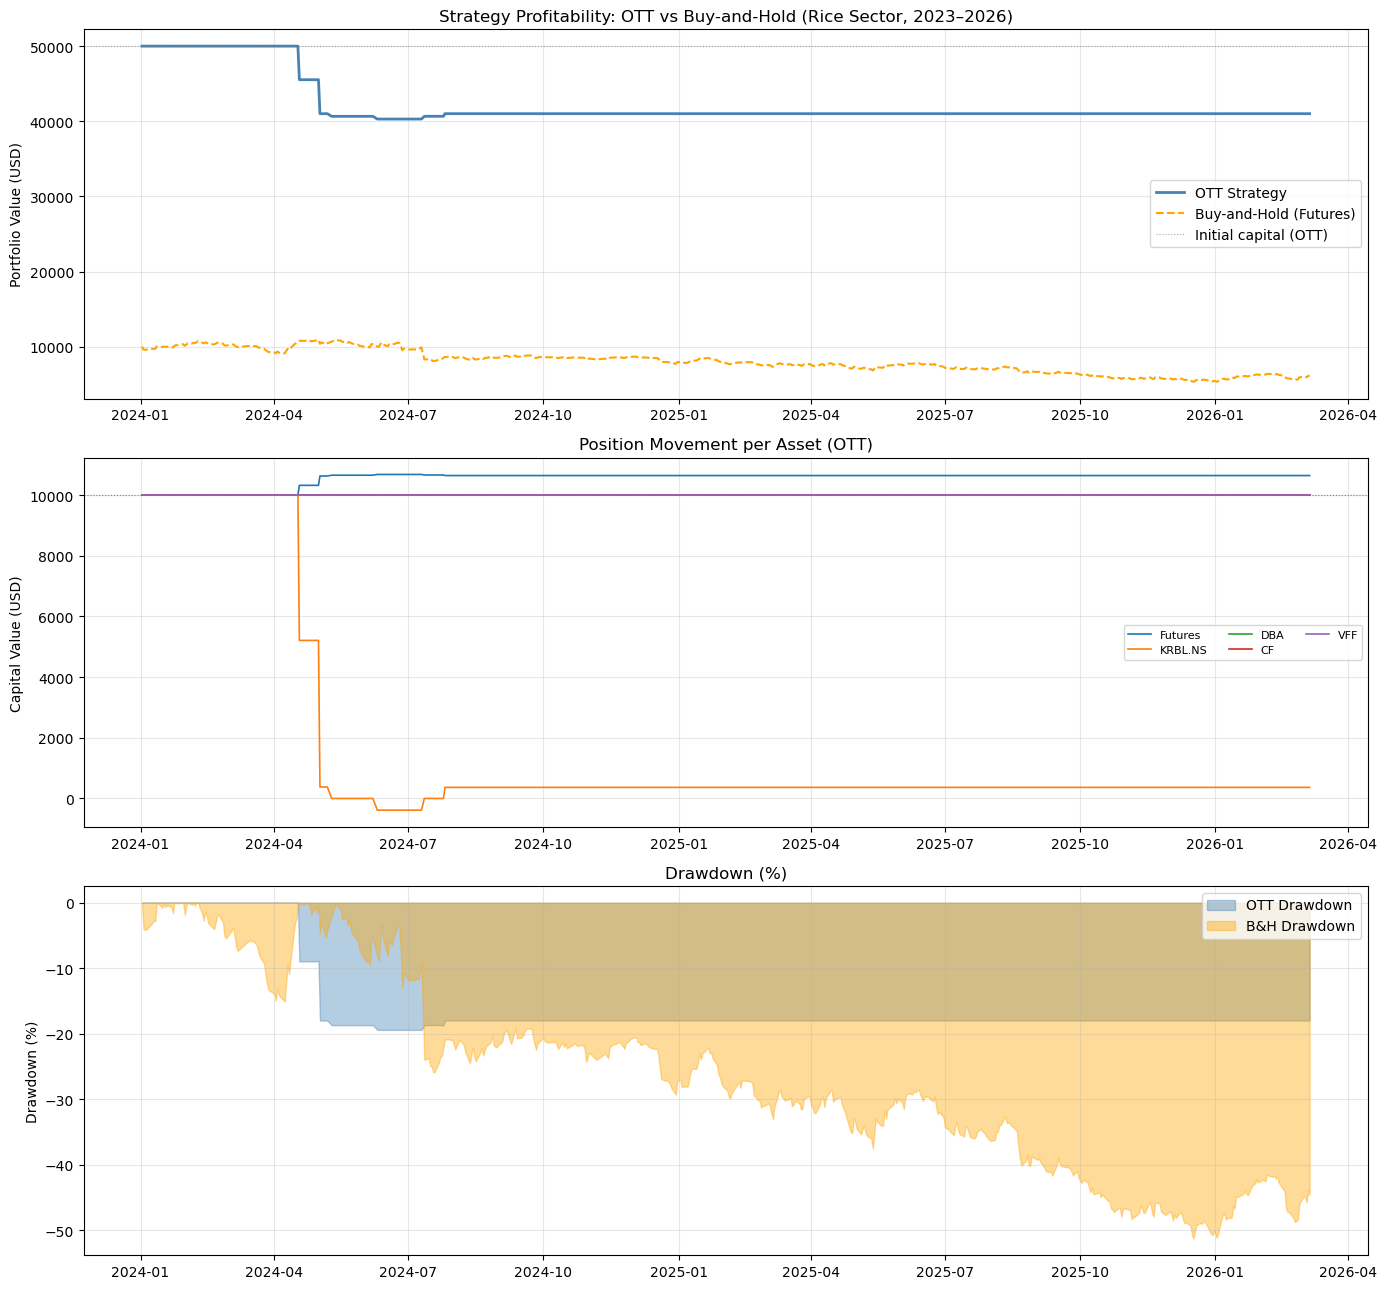

In [28]:
# =============================================================================
# FINAL VISUALIZATION: OTT vs Buy-and-Hold (Figure 6 analog from the paper)
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# --- Plot 1: Portfolio values ---
axes[0].plot(port_df.index, port_df['Total_OTT'], label='OTT Strategy',
             color='steelblue', linewidth=2)
axes[0].plot(port_df.index, port_df['BuyAndHold'], label='Buy-and-Hold (Futures)',
             color='orange', linestyle='--', linewidth=1.5)
axes[0].axhline(ott_start, color='gray', linestyle=':', linewidth=0.8, alpha=0.7, label='Initial capital (OTT)')
axes[0].set_title('Strategy Profitability: OTT vs Buy-and-Hold (Rice Sector, 2023–2026)', fontsize=12)
axes[0].set_ylabel('Portfolio Value (USD)')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Plot 2: Individual asset position movements (like Figure 4b in the paper) ---
for idx_str in [k for k in trading_weights.keys() if k in port_df.columns]:
    asset_name = lookup.get(idx_str, idx_str)
    axes[1].plot(port_df.index, port_df[idx_str], label=asset_name, linewidth=1.2)
axes[1].axhline(ORIG_AMOUNT, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_title('Position Movement per Asset (OTT)', fontsize=12)
axes[1].set_ylabel('Capital Value (USD)')
axes[1].legend(fontsize=8, ncol=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Plot 3: Drawdown ---
ott_dd = (port_df['Total_OTT'] - port_df['Total_OTT'].cummax()) / port_df['Total_OTT'].cummax()
bh_dd  = (port_df['BuyAndHold'] - port_df['BuyAndHold'].cummax()) / port_df['BuyAndHold'].cummax()
axes[2].fill_between(port_df.index, ott_dd * 100, 0, alpha=0.4, color='steelblue', label='OTT Drawdown')
axes[2].fill_between(port_df.index, bh_dd  * 100, 0, alpha=0.4, color='orange',    label='B&H Drawdown')
axes[2].set_title('Drawdown (%)', fontsize=12)
axes[2].set_ylabel('Drawdown (%)')
axes[2].legend(fontsize=10)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [29]:
# =============================================================================
# SUMMARY COMPARISON TABLE
# =============================================================================

summary = pd.DataFrame([
    {
        'Strategy'           : 'OTT (λ={:.1f}, TC=10bps)'.format(LAMBDA),
        'Ann. Return (%)'    : round(metrics_ott['ann_return']*100, 2),
        'Ann. Volatility (%)': round(metrics_ott['ann_vol']*100, 2),
        'Sharpe Ratio'       : round(metrics_ott['sharpe'], 4),
        'Max Drawdown (%)'   : round(metrics_ott['max_dd']*100, 2),
        'Calmar Ratio'       : round(metrics_ott['calmar'], 4),
        'End Value (USD)'    : round(metrics_ott['end_value'], 2),
    },
    {
        'Strategy'           : 'Buy-and-Hold (Rice Futures)',
        'Ann. Return (%)'    : round(metrics_bh['ann_return']*100, 2),
        'Ann. Volatility (%)': round(metrics_bh['ann_vol']*100, 2),
        'Sharpe Ratio'       : round(metrics_bh['sharpe'], 4),
        'Max Drawdown (%)'   : round(metrics_bh['max_dd']*100, 2),
        'Calmar Ratio'       : round(metrics_bh['calmar'], 4),
        'End Value (USD)'    : round(metrics_bh['end_value'], 2),
    },
])

summary = summary.set_index('Strategy')
print("\nPerformance Summary — Trading Game #1 (Rice Sector, 2023–2026):")
print(summary.to_string())


Performance Summary — Trading Game #1 (Rice Sector, 2023–2026):
                             Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio  End Value (USD)
Strategy                                                                                                                        
OTT (λ=1.0, TC=10bps)                -9.0600               9.3300       -1.3997          -19.4100       -0.6728       41008.1100
Buy-and-Hold (Rice Futures)         -21.4400              26.2400       -0.9693          -51.2700       -0.4962        6043.0800


---
## 9. Conclusion

This notebook has implemented the **Optimal Trading Technique (OTT)** from Yang & Malik (2024) and adapted it to the **rice commodity sector**.

### Key Adaptations vs. the Original Paper

| Dimension | Yang & Malik (2024) | This Work |
|---|---|---|
| Market | Cryptocurrency (ETH) | Rice commodity sector |
| Anchor | ETH as intermediate | Rice Futures (CBOT) |
| Assets | 4 fiat currencies | Rice equities (KRBL, ADM, BG, DBA, AGRO) |
| Frequency | 1-min / 5-min / 60-min | Daily |
| Formation | 2018–2020 | 2020–2022 |
| Trading | 2020–2022 | 2023–2026 |

### Methodology Followed (Article Steps)

1. **Screening** (Section 3.1): Pearson correlation + Engle-Granger cointegration on the formation period
2. **Signal generation** (Section 3.2): Z-score of OLS residuals with open/close thresholds
3. **Optimization** (Section 3.3): Bi-objective Gurobi model (Eq. 6) balancing return vs risk
4. **Simulation** (Section 4, Algorithm 1): Out-of-sample backtesting on 2023–2026
5. **Evaluation** (Section 5.4): Sharpe Ratio, Max Drawdown, Calmar Ratio vs Buy-and-Hold

### Limitations & Future Work

- Daily data provides fewer arbitrage opportunities than the minute-frequency data in the paper
- Rice-related equities have lower cross-market synchronisation than ETH/fiat pairs
- The threshold parameters (OPEN/CLOSE) could be further optimized via grid search (Figure 5 of the paper)
- Future extensions: Ornstein-Uhlenbeck process modeling of spreads, dynamic rolling windows